In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Установки визуализации
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Загрузка данных Rossmann
train_df = pd.read_csv('data/train.csv', low_memory=False)
store_df = pd.read_csv('data/store.csv')

train_df['Date'] = pd.to_datetime(train_df['Date'])
print(f"Train shape: {train_df.shape}")
print(f"Store metadata shape: {store_df.shape}")
train_df.head()

Train shape: (1017209, 9)
Store metadata shape: (1115, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [17]:
print("--- Пропущенные значения в train ---")
print(train_df.isnull().sum())

print("\n--- Пропущенные значения в store ---")
print(store_df.isnull().sum())

# Фильтрация только открытых магазинов с продажами > 0 для корректного EDA
active_sales = train_df[(train_df['Open'] == 1) & (train_df['Sales'] > 0)]
print(f"\nЗаписей с активными продажами: {len(active_sales):,}")

--- Пропущенные значения в train ---
Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

--- Пропущенные значения в store ---
Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

Записей с активными продажами: 844,338


In [18]:
store_1 = active_sales[active_sales['Store'] == 1].sort_values('Date')

fig = px.line(
    store_1,
    x='Date',
    y='Sales',
    color='Promo',
    title='Динамика дневных продаж Store #1 (Зависимость от Промо-акций)',
    labels={'Sales': 'Продажи (€)', 'Date': 'Дата', 'Promo': 'Промо'}
)
fig.show()

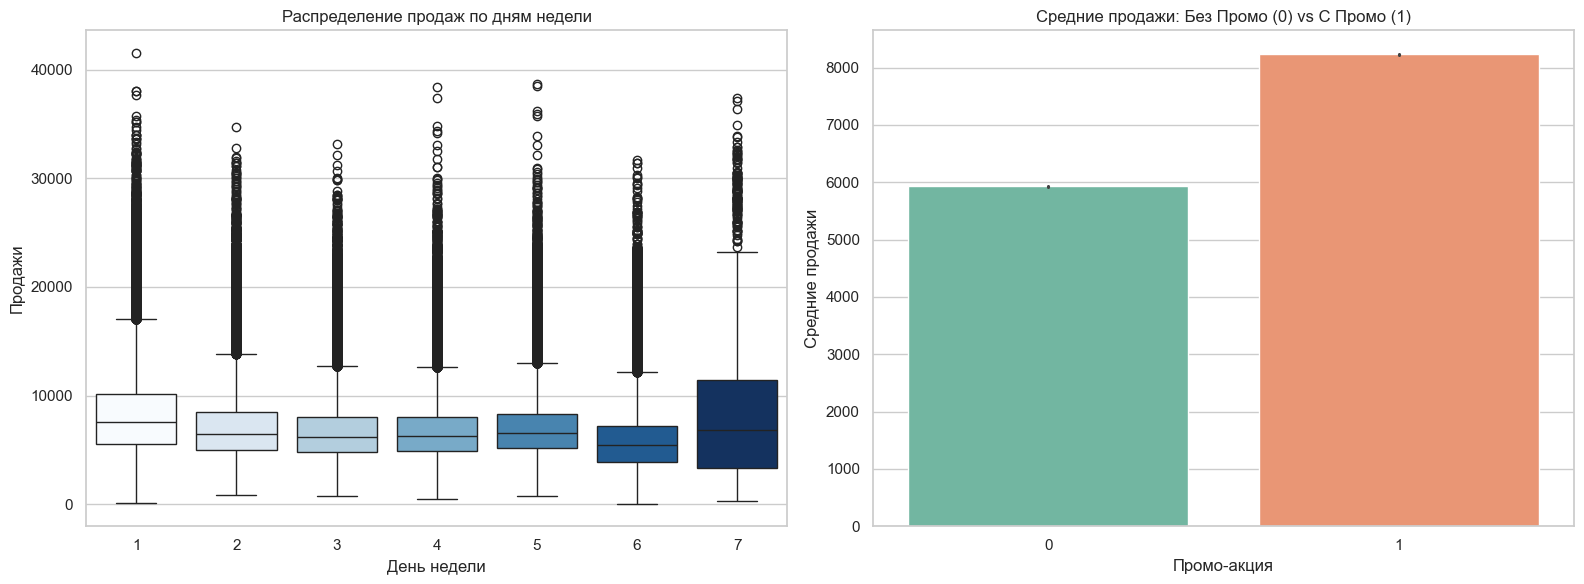

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Продажи по дням недели (1 - Понедельник, 7 - Воскресенье)
sns.boxplot(
    data=active_sales,
    x='DayOfWeek',
    y='Sales',
    hue='DayOfWeek',
    legend=False,
    ax=axes[0],
    palette='Blues',
)
axes[0].set_title('Распределение продаж по дням недели')
axes[0].set_xlabel('День недели')
axes[0].set_ylabel('Продажи')

# Влияние промо на продажи
sns.barplot(
    data=active_sales,
    x='Promo',
    y='Sales',
    hue='Promo',
    legend=False,
    ax=axes[1],
    palette='Set2',
)
axes[1].set_title('Средние продажи: Без Промо (0) vs С Промо (1)')
axes[1].set_xlabel('Промо-акция')
axes[1].set_ylabel('Средние продажи')

plt.tight_layout()
plt.show()

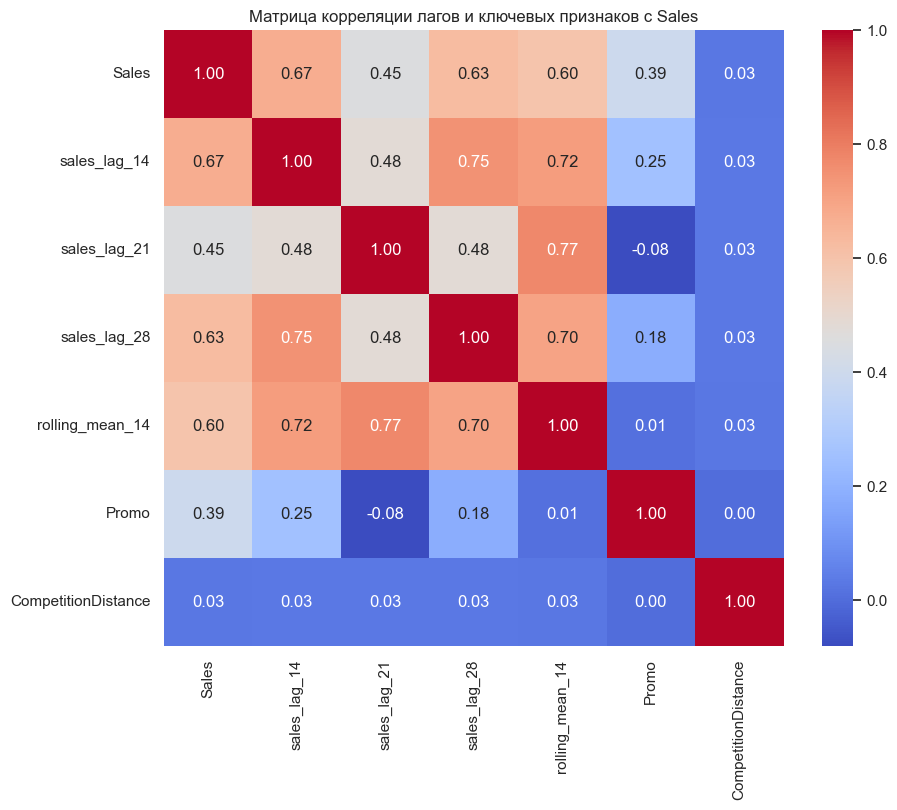

In [20]:
from app.feature_engineering import prepare_features

# Генерация лагов через наш пайплайн
df_featured = prepare_features(train_df, store_df=store_df, is_train=True).dropna()

# Корреляция продаж с лагами и скользящими средними
lag_cols = ['Sales', 'sales_lag_14', 'sales_lag_21', 'sales_lag_28', 'rolling_mean_14', 'Promo', 'CompetitionDistance']
corr_matrix = df_featured[lag_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Матрица корреляции лагов и ключевых признаков с Sales")
plt.show()

In [24]:
import importlib
import joblib
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import app.feature_engineering

# Force-reload module to register IsPayday, Sin_DayOfYear, and Cos_DayOfYear
importlib.reload(app.feature_engineering)
from app.feature_engineering import prepare_features

# 1. Load raw data
train_df = pd.read_csv('data/train.csv', low_memory=False)
store_df = pd.read_csv('data/store.csv')

# 2. Filter open days and engineer features
train_df_open = train_df[
    (train_df['Open'] == 1) & (train_df['Sales'] > 0)
].copy()
df_featured = prepare_features(
    train_df_open, store_df=store_df, is_train=True
)

# 3. Load ensemble model artifact & features
artifact = joblib.load('models/lgbm_demand_model.pkl')
feature_cols = artifact['feature_cols']

# Extract model list safely
models = artifact.get('models', [artifact.get('model')])

# Fill missing values with median
for col in feature_cols:
  if col in df_featured.columns:
    df_featured[col] = df_featured[col].fillna(df_featured[col].median())

# 4. Validation slice (Last 30 days)
max_date = df_featured['Date'].max()
split_date = max_date - pd.Timedelta(days=30)
val_df = df_featured[df_featured['Date'] > split_date].copy()

# 5. Ensemble prediction across all 5 folds
preds_log_matrix = np.column_stack(
    [m.predict(val_df[feature_cols]) for m in models]
)
avg_preds_log = np.mean(preds_log_matrix, axis=1)
val_df['Predicted_Sales'] = np.expm1(avg_preds_log)

# 6. Plot Store #1 Actual vs Forecast
store_1 = val_df[val_df['Store'] == 1].sort_values('Date')

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=store_1['Date'],
        y=store_1['Sales'],
        mode='lines+markers',
        name='Actual Sales',
    )
)
fig.add_trace(
    go.Scatter(
        x=store_1['Date'],
        y=store_1['Predicted_Sales'],
        mode='lines+markers',
        name='5-Fold Ensemble Forecast',
        line=dict(dash='dash', color='red'),
    )
)

fig.update_layout(
    title='Store #1: Actual vs 5-Fold Ensemble Forecast (Validation Period)',
    xaxis_title='Date',
    yaxis_title='Sales (€)',
)
fig.show()

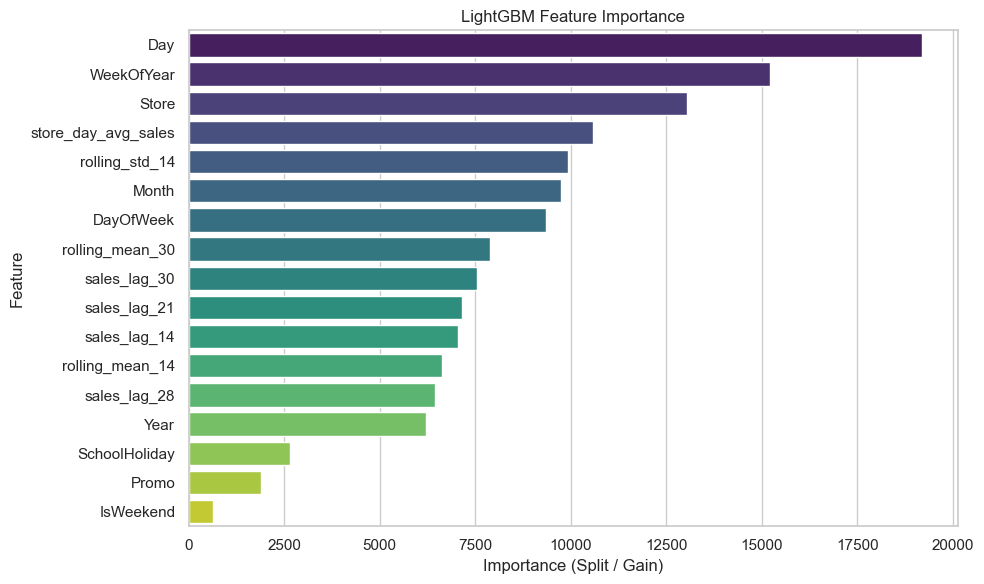

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Усредняем важность признаков по всем фолдам ансамбля
importance = np.mean([m.feature_importances_ for m in models], axis=0)

feature_imp = (
    pd.DataFrame({'Feature': feature_cols, 'Importance': importance})
    .sort_values(by='Importance', ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_imp,
    hue='Feature',
    palette='viridis',
    legend=False,
)
plt.title('Ensemble LightGBM Feature Importance (Mean Across 5 Folds)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()